In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data
df_stock = pd.read_csv('stock_data_with_spy.csv', parse_dates=['date'])
price_df = df_stock.pivot(index='date', columns='ticker', values='prc')
returns_df = df_stock.pivot(index='date', columns='ticker', values='ret')

print("Data loaded!")
print("Tickers:", price_df.columns.tolist())
print(df_stock.head())

Data loaded!
Tickers: ['AAPL', 'GOOGL', 'MSFT', 'SPY']
        date  permno        prc       ret          vol ticker
0 2023-01-03   10107  239.58000 -0.001001   25723760.0   MSFT
1 2023-01-03   14542   89.70000  0.010932   20710597.0  GOOGL
2 2023-01-03   14593  125.07000 -0.037405  111953221.0   AAPL
3 2023-01-03   84398  380.82001 -0.004210   74850731.0    SPY
4 2023-01-04   10107  229.10001 -0.043743   50564994.0   MSFT


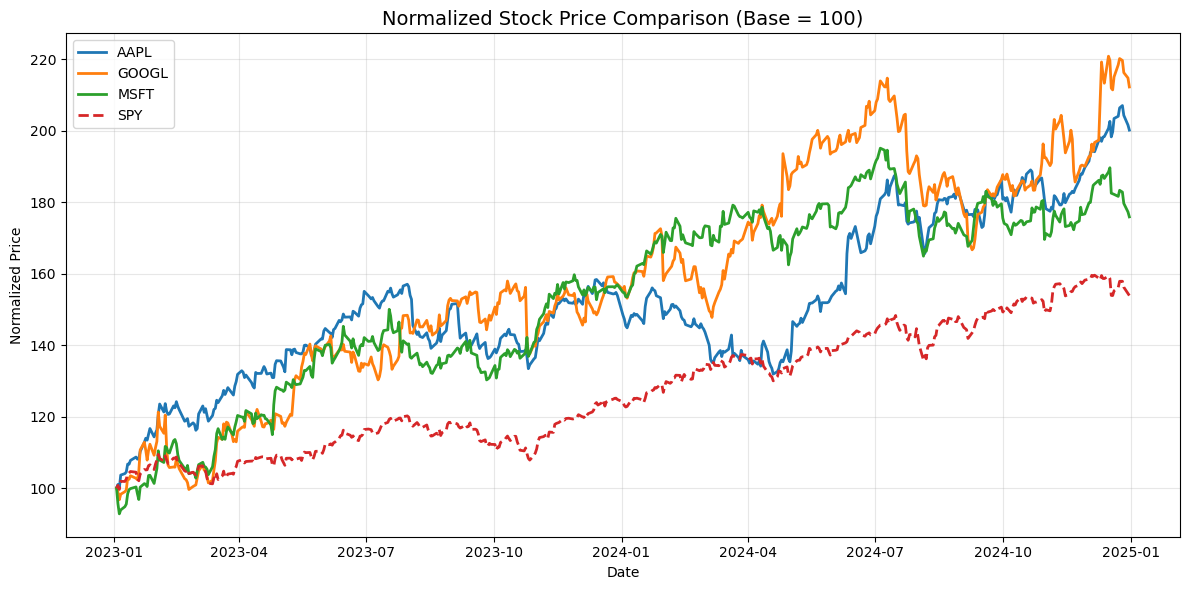

In [2]:
# Normalized Price Comparison (all stocks including SPY)
normalized = price_df / price_df.iloc[0] * 100

plt.figure(figsize=(12, 6))
for ticker in normalized.columns:
    linestyle = '--' if ticker == 'SPY' else '-'
    plt.plot(normalized.index, normalized[ticker], label=ticker, linewidth=2, linestyle=linestyle)

plt.title('Normalized Stock Price Comparison (Base = 100)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('normalized_price.png', dpi=150)
plt.show()

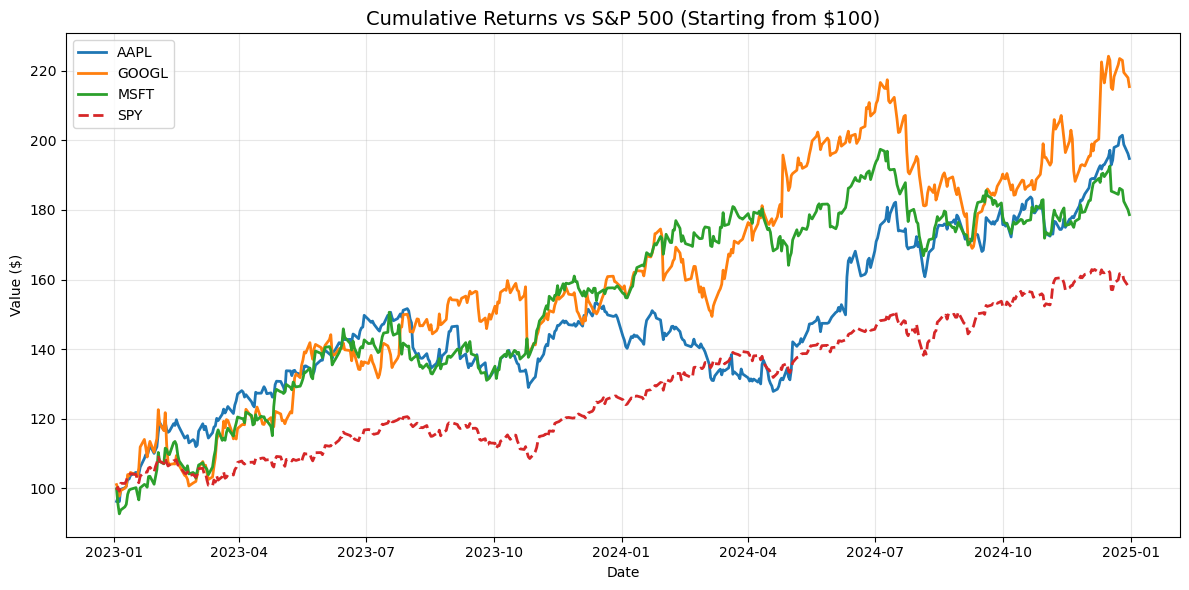

In [3]:
# Cumulative Returns vs S&P 500
cumulative_returns = (1 + returns_df).cumprod() * 100

plt.figure(figsize=(12, 6))
for ticker in cumulative_returns.columns:
    linestyle = '--' if ticker == 'SPY' else '-'
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker, linewidth=2, linestyle=linestyle)

plt.title('Cumulative Returns vs S&P 500 (Starting from $100)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_vs_spy.png', dpi=150)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_113416\3026029884.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = returns_df[['AAPL', 'MSFT', 'GOOGL']].resample('M').apply(lambda x: (1 + x).prod() - 1)


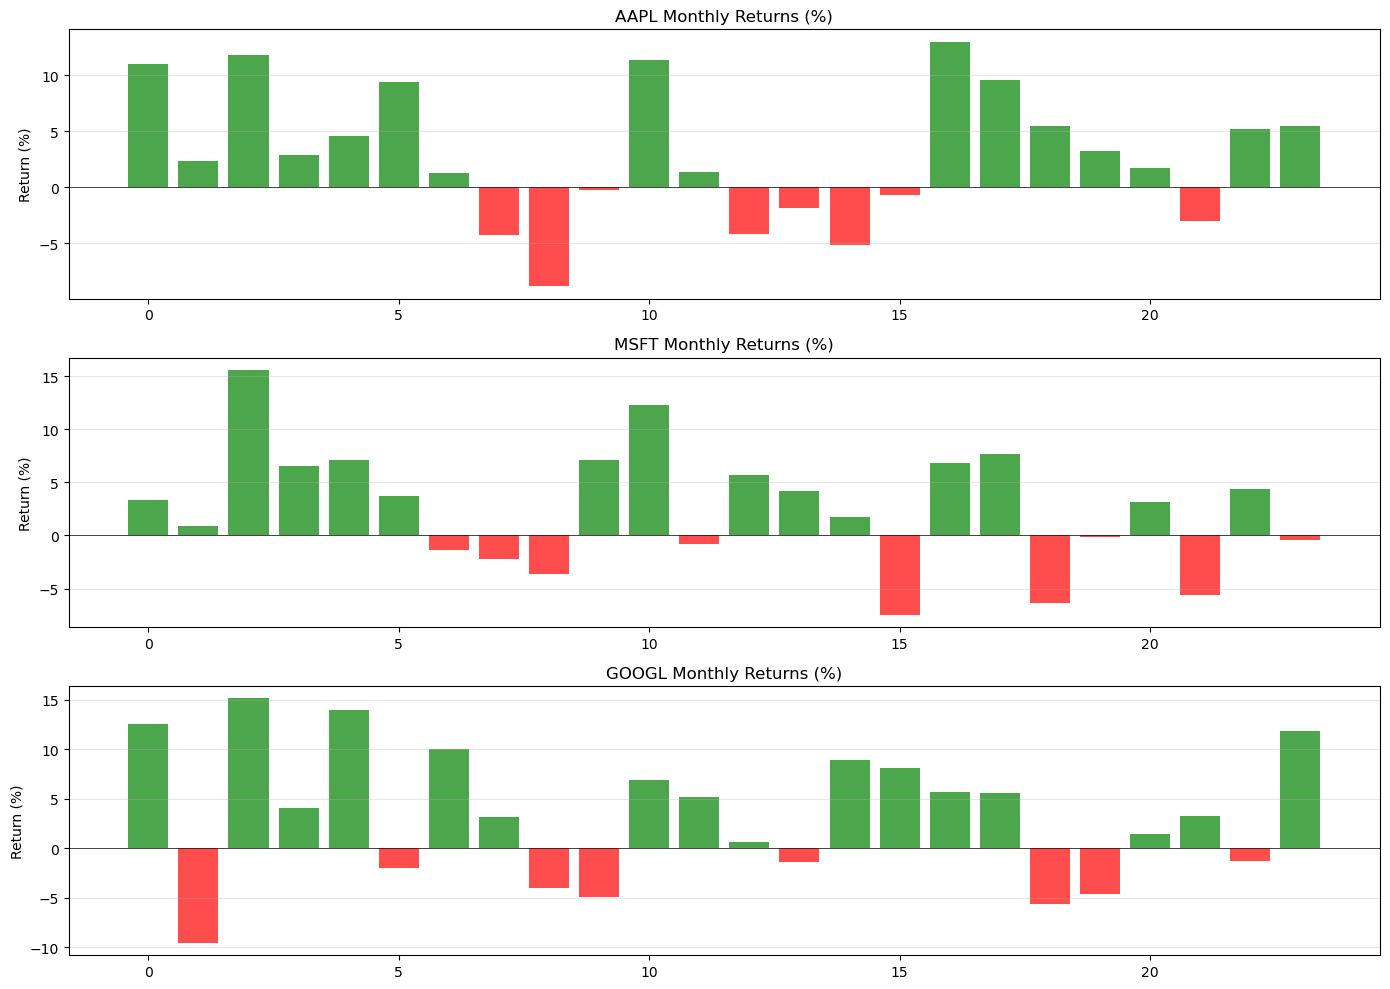

In [4]:
# Monthly Returns (AAPL, MSFT, GOOGL only)
monthly_returns = returns_df[['AAPL', 'MSFT', 'GOOGL']].resample('M').apply(lambda x: (1 + x).prod() - 1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, ticker in enumerate(['AAPL', 'MSFT', 'GOOGL']):
    ax = axes[i]
    data = monthly_returns[ticker] * 100
    colors_bar = ['green' if x >= 0 else 'red' for x in data]
    ax.bar(range(len(data)), data, color=colors_bar, alpha=0.7)
    ax.set_title(f'{ticker} Monthly Returns (%)', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('Return (%)')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('monthly_returns.png', dpi=150)
plt.show()

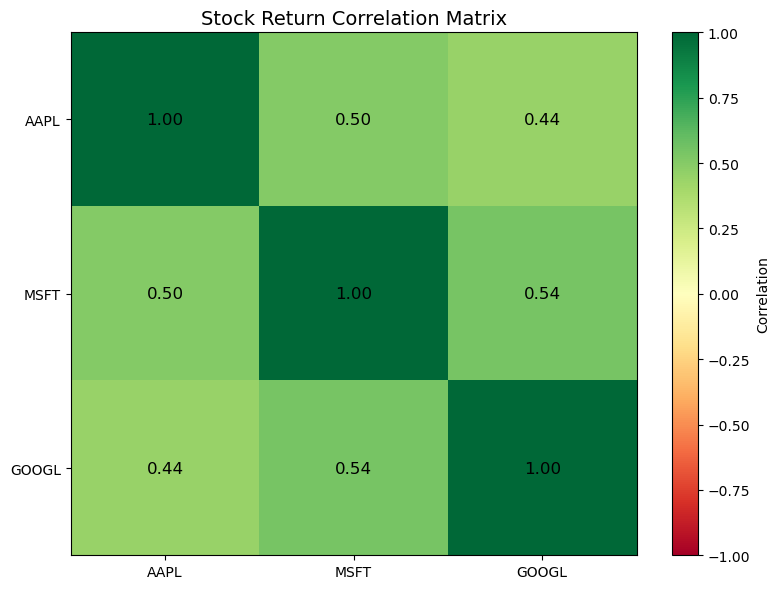

In [5]:
# Correlation Matrix (AAPL, MSFT, GOOGL only)
correlation = returns_df[['AAPL', 'MSFT', 'GOOGL']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns)
ax.set_yticklabels(correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, f'{correlation.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=12)

plt.colorbar(im, label='Correlation')
plt.title('Stock Return Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

In [6]:
# Key Metrics Comparison
print("="*60)
print("PERFORMANCE VS S&P 500")
print("="*60)

spy_return = (price_df['SPY'].iloc[-1] / price_df['SPY'].iloc[0] - 1) * 100

for ticker in price_df.columns:
    prices = price_df[ticker].dropna()
    returns = returns_df[ticker].dropna()
    total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
    annual_vol = returns.std() * (252**0.5) * 100
    
    print(f"\n{ticker}:")
    print(f"  Total Return: {total_return:.2f}%")
    print(f"  Annual Volatility: {annual_vol:.2f}%")
    
    if ticker != 'SPY':
        excess = total_return - spy_return
        print(f"  Excess Return vs SPY: {excess:.2f}%")

PERFORMANCE VS S&P 500

AAPL:
  Total Return: 100.22%
  Annual Volatility: 21.51%
  Excess Return vs SPY: 46.32%

GOOGL:
  Total Return: 112.31%
  Annual Volatility: 29.15%
  Excess Return vs SPY: 58.41%

MSFT:
  Total Return: 75.93%
  Annual Volatility: 22.66%
  Excess Return vs SPY: 22.03%

SPY:
  Total Return: 53.90%
  Annual Volatility: 12.81%


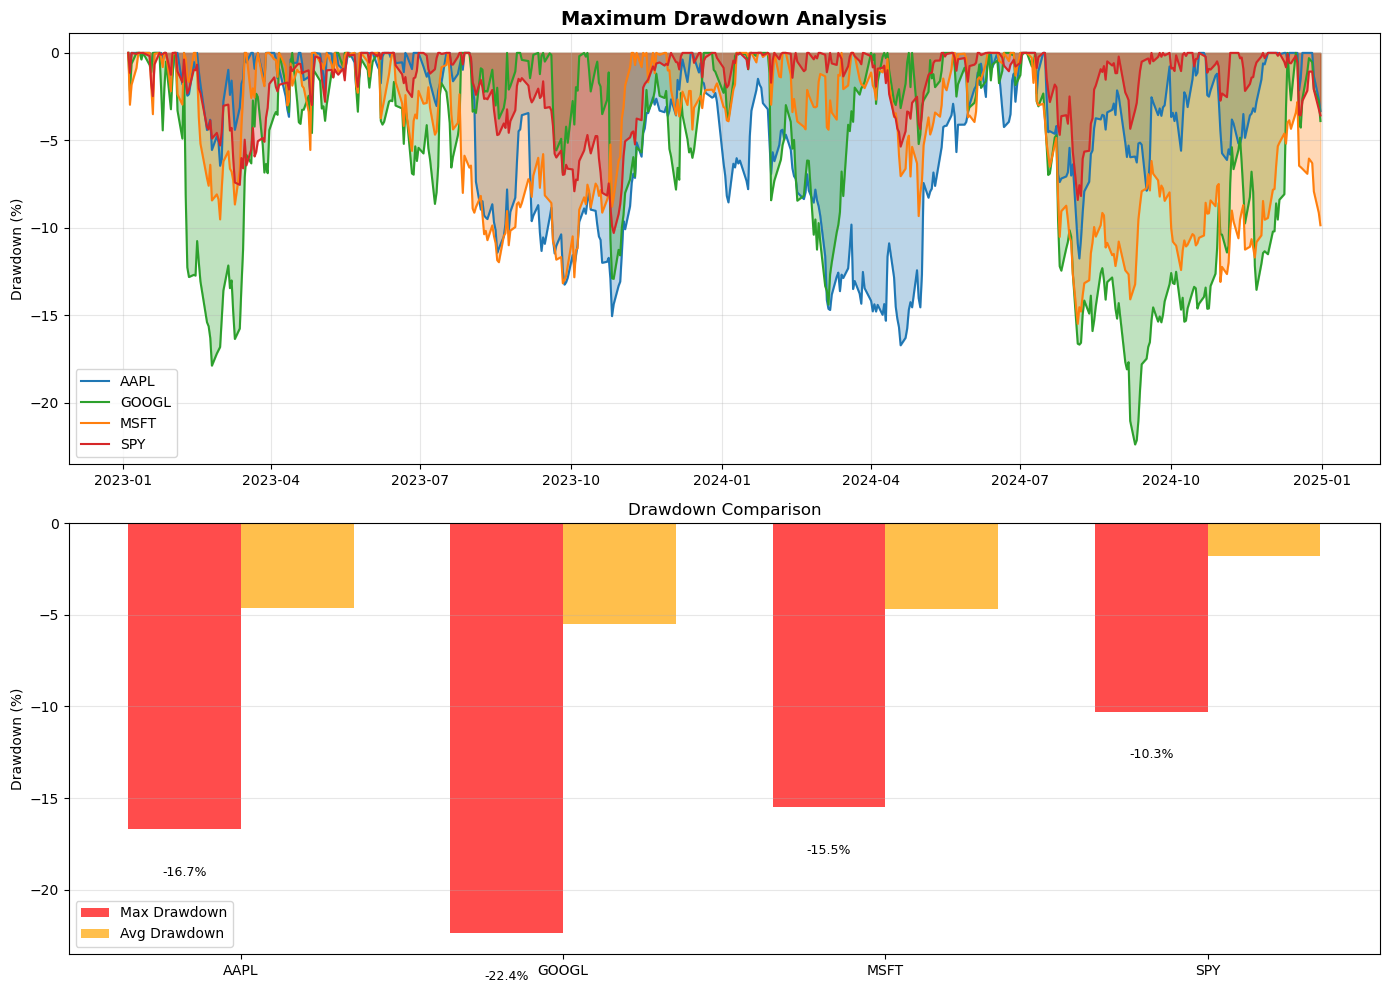


DRAWDOWN ANALYSIS

AAPL:
  Maximum Drawdown: -16.71%
  Average Drawdown: -4.63%

GOOGL:
  Maximum Drawdown: -22.38%
  Average Drawdown: -5.49%

MSFT:
  Maximum Drawdown: -15.49%
  Average Drawdown: -4.70%

SPY:
  Maximum Drawdown: -10.29%
  Average Drawdown: -1.77%


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data
df_stock = pd.read_csv('stock_data_with_spy.csv', parse_dates=['date'])
price_df = df_stock.pivot(index='date', columns='ticker', values='prc')

# Calculate Maximum Drawdown
def calculate_drawdown(prices):
    cumulative = (1 + prices.pct_change()).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max * 100
    return drawdown

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1: Drawdown curves
ax1 = axes[0]
colors = {'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c', 'SPY': '#d62728'}
for ticker in price_df.columns:
    drawdown = calculate_drawdown(price_df[ticker])
    ax1.fill_between(drawdown.index, 0, drawdown, alpha=0.3, color=colors[ticker])
    ax1.plot(drawdown.index, drawdown, label=ticker, color=colors[ticker], linewidth=1.5)

ax1.set_title('Maximum Drawdown Analysis', fontsize=14, fontweight='bold')
ax1.set_ylabel('Drawdown (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Risk metrics bar chart
ax2 = axes[1]
metrics = {}
for ticker in price_df.columns:
    drawdown = calculate_drawdown(price_df[ticker])
    max_dd = drawdown.min()
    avg_dd = drawdown.mean()
    metrics[ticker] = {'Max Drawdown': max_dd, 'Avg Drawdown': avg_dd}

x = np.arange(len(metrics))
width = 0.35

max_dds = [metrics[t]['Max Drawdown'] for t in metrics]
avg_dds = [metrics[t]['Avg Drawdown'] for t in metrics]

bars1 = ax2.bar(x - width/2, max_dds, width, label='Max Drawdown', color='red', alpha=0.7)
bars2 = ax2.bar(x + width/2, avg_dds, width, label='Avg Drawdown', color='orange', alpha=0.7)

ax2.set_title('Drawdown Comparison', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics.keys())
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2, 
             f'{bar.get_height():.1f}%', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.savefig('drawdown_analysis.png', dpi=150)
plt.show()

# Print results
print("\n" + "="*50)
print("DRAWDOWN ANALYSIS")
print("="*50)
for ticker in metrics:
    print(f"\n{ticker}:")
    print(f"  Maximum Drawdown: {metrics[ticker]['Max Drawdown']:.2f}%")
    print(f"  Average Drawdown: {metrics[ticker]['Avg Drawdown']:.2f}%")

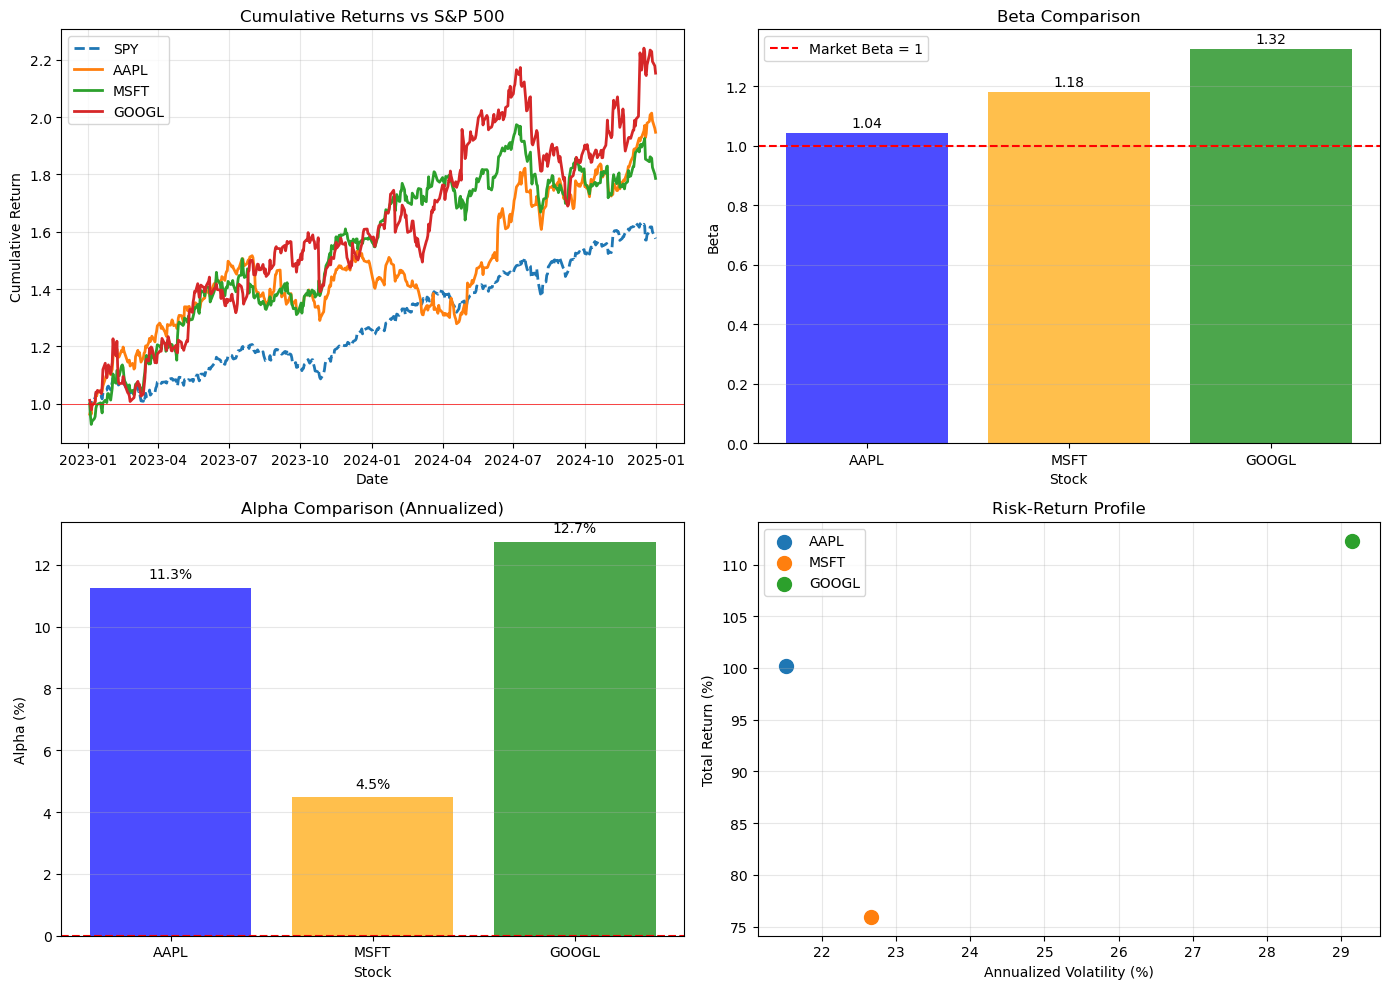


BETA AND ALPHA ANALYSIS

AAPL:
  Beta: 1.04
  Alpha (Annualized): 11.26%

MSFT:
  Beta: 1.18
  Alpha (Annualized): 4.49%

GOOGL:
  Beta: 1.32
  Alpha (Annualized): 12.75%


In [8]:
# Calculate Beta and Alpha
betas = {}
alphas = {}
spy_returns = returns_df['SPY'].dropna()
risk_free_rate = 0.04 / 252

for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    stock_returns = returns_df[ticker].dropna()
    covariance = stock_returns.cov(spy_returns)
    market_variance = spy_returns.var()
    beta = covariance / market_variance
    betas[ticker] = beta
    
    stock_annual_return = stock_returns.mean() * 252
    market_annual_return = spy_returns.mean() * 252
    alpha = stock_annual_return - (risk_free_rate * 252 + beta * (market_annual_return - risk_free_rate * 252))
    alphas[ticker] = alpha * 100

# Create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cumulative Returns vs S&P 500
ax1 = axes[0, 0]
cumulative = (1 + returns_df).cumprod()
for ticker in ['SPY', 'AAPL', 'MSFT', 'GOOGL']:
    linestyle = '--' if ticker == 'SPY' else '-'
    ax1.plot(cumulative.index, cumulative[ticker], label=ticker, linestyle=linestyle, linewidth=2)
ax1.axhline(y=1.0, color='red', linestyle='-', linewidth=0.5)
ax1.set_title('Cumulative Returns vs S&P 500', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Beta Comparison
ax2 = axes[0, 1]
tickers = list(betas.keys())
beta_values = list(betas.values())
bars = ax2.bar(tickers, beta_values, color=['blue', 'orange', 'green'], alpha=0.7)
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Market Beta = 1')
ax2.set_title('Beta Comparison', fontsize=12)
ax2.set_xlabel('Stock')
ax2.set_ylabel('Beta')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, beta_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=10)

# 3. Alpha Comparison
ax3 = axes[1, 0]
alpha_values = list(alphas.values())
bars = ax3.bar(tickers, alpha_values, color=['blue', 'orange', 'green'], alpha=0.7)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax3.set_title('Alpha Comparison (Annualized)', fontsize=12)
ax3.set_xlabel('Stock')
ax3.set_ylabel('Alpha (%)')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, alpha_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=10)

# 4. Risk-Return Profile
ax4 = axes[1, 1]
for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    returns = returns_df[ticker].dropna()
    total_return = (price_df[ticker].iloc[-1] / price_df[ticker].iloc[0] - 1) * 100
    annual_vol = returns.std() * (252**0.5) * 100
    ax4.scatter(annual_vol, total_return, s=100, label=ticker)
ax4.set_title('Risk-Return Profile', fontsize=12)
ax4.set_xlabel('Annualized Volatility (%)')
ax4.set_ylabel('Total Return (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150)
plt.show()

# Print Beta and Alpha
print("\n" + "="*50)
print("BETA AND ALPHA ANALYSIS")
print("="*50)
for ticker in tickers:
    print(f"\n{ticker}:")
    print(f"  Beta: {betas[ticker]:.2f}")
    print(f"  Alpha (Annualized): {alphas[ticker]:.2f}%")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_113416\1408156545.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret = mean_returns[i]


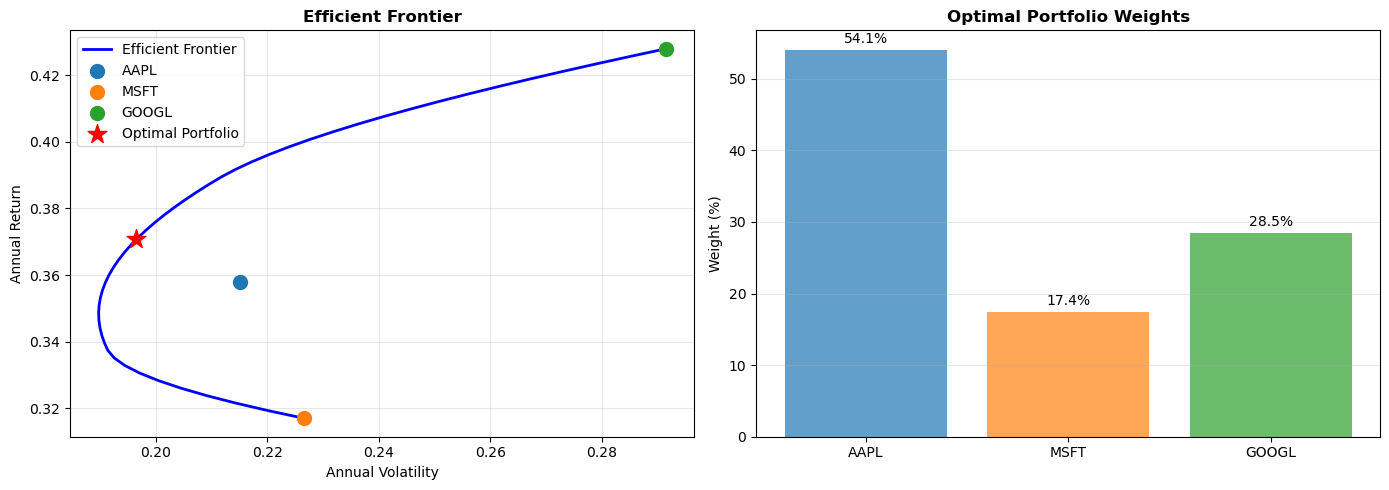


OPTIMAL PORTFOLIO ALLOCATION

AAPL: 54.1%
MSFT: 17.4%
GOOGL: 28.5%

Expected Annual Return: 37.07%
Expected Annual Volatility: 19.65%
Sharpe Ratio: 1.68


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# Read data
df_stock = pd.read_csv('stock_data_with_spy.csv', parse_dates=['date'])
returns_df = df_stock.pivot(index='date', columns='ticker', values='ret')
returns_df = returns_df[['AAPL', 'MSFT', 'GOOGL']]

# Calculate mean returns and covariance
mean_returns = returns_df.mean() * 252
cov_matrix = returns_df.cov() * 252

# Portfolio optimization functions
def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def negative_sharpe(weights, mean_returns, cov_matrix, rf=0.04):
    ret = portfolio_return(weights, mean_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    return -(ret - rf) / vol

# Constraints
num_assets = 3
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = num_assets * [1. / num_assets]

# Optimize for maximum Sharpe Ratio
opt_result = minimize(negative_sharpe, initial_guess, 
                      args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = opt_result.x

# Generate efficient frontier
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)
efficient_portfolios = []

for target in target_returns:
    constraints_eff = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: portfolio_return(x, mean_returns) - target}
    ]
    result = minimize(portfolio_volatility, initial_guess,
                      args=(cov_matrix,), method='SLSQP',
                      bounds=bounds, constraints=constraints_eff)
    efficient_portfolios.append(result.fun)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Efficient Frontier
ax1 = axes[0]
ax1.plot(efficient_portfolios, target_returns, 'b-', linewidth=2, label='Efficient Frontier')

# Mark individual stocks
for i, ticker in enumerate(['AAPL', 'MSFT', 'GOOGL']):
    vol = np.sqrt(cov_matrix.iloc[i, i])
    ret = mean_returns[i]
    ax1.scatter(vol, ret, s=100, label=ticker, zorder=5)

# Mark optimal portfolio
opt_ret = portfolio_return(optimal_weights, mean_returns)
opt_vol = portfolio_volatility(optimal_weights, cov_matrix)
ax1.scatter(opt_vol, opt_ret, s=200, marker='*', color='red', 
            label='Optimal Portfolio', zorder=6)

ax1.set_title('Efficient Frontier', fontsize=12, fontweight='bold')
ax1.set_xlabel('Annual Volatility')
ax1.set_ylabel('Annual Return')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Optimal Weights
ax2 = axes[1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax2.bar(['AAPL', 'MSFT', 'GOOGL'], optimal_weights * 100, color=colors, alpha=0.7)
ax2.set_title('Optimal Portfolio Weights', fontsize=12, fontweight='bold')
ax2.set_ylabel('Weight (%)')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, optimal_weights * 100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('portfolio_optimization.png', dpi=150)
plt.show()

# Print results
print("\n" + "="*50)
print("OPTIMAL PORTFOLIO ALLOCATION")
print("="*50)
print(f"\nAAPL: {optimal_weights[0]*100:.1f}%")
print(f"MSFT: {optimal_weights[1]*100:.1f}%")
print(f"GOOGL: {optimal_weights[2]*100:.1f}%")
print(f"\nExpected Annual Return: {opt_ret*100:.2f}%")
print(f"Expected Annual Volatility: {opt_vol*100:.2f}%")
print(f"Sharpe Ratio: {(opt_ret - 0.04) / opt_vol:.2f}")

In [10]:
df_stock.to_csv('stock_data.csv', index=False)

In [11]:
import pandas as pd

df_stock = pd.read_csv('stock_data_with_spy.csv', parse_dates=['date'])
print("All tickers in your CSV:")
print(df_stock['ticker'].unique())

All tickers in your CSV:
['MSFT' 'GOOGL' 'AAPL' 'SPY']
